# PROYECTO FINAL

# Obtenemos Datos con API

In [78]:
import os

# El nombre de usuario es el que aparece en tu URL de Kaggle (ej: 'juanperez')
os.environ['KAGGLE_USERNAME'] = "danieldelgado23"

# Aquí pega el código largo (Token) que te generó la página de tu imagen
os.environ['KAGGLE_KEY'] = "KGAT_d569c08c514f70167820700b42051e32"

In [79]:
import kaggle

# Definimos el dataset y la ruta donde lo quieres guardar
dataset = 'shekpaul/global-superstore'
ruta = '../data/raw/'

# Descarga y descomprime
kaggle.api.dataset_download_files(dataset, path=ruta, unzip=True)

print("¡Listo! El archivo ya debe estar en tu carpeta ../data/raw/")

Dataset URL: https://www.kaggle.com/datasets/shekpaul/global-superstore


¡Listo! El archivo ya debe estar en tu carpeta ../data/raw/


In [80]:
import pandas as pd

# 1. Ruta corregida (Saliendo de 'src')
file_path = '../data/raw/Global Superstore.xls'

# 2. Intentamos leer como Excel real (necesitas instalar: pip install xlrd)
try:
    df = pd.read_excel(file_path)
    print("¡Cargado como Excel!")
except:
    # 3. Si falla, es que es un HTML disfrazado
    try:
        tablas = pd.read_html(file_path)
        df = tablas[0]
        print("¡Cargado como Tabla HTML!")
    except Exception as e:
        print(f"Sigue fallando. Error: {e}")

# Si logramos cargar algo, limpiamos nombres de columnas
if 'df' in locals():
    df.columns = [col.strip().replace(' ', '_').lower() for col in df.columns]
    display(df.head())

¡Cargado como Excel!


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


# AHORA SI!

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row_id          51290 non-null  int64         
 1   order_id        51290 non-null  str           
 2   order_date      51290 non-null  datetime64[us]
 3   ship_date       51290 non-null  datetime64[us]
 4   ship_mode       51290 non-null  str           
 5   customer_id     51290 non-null  str           
 6   customer_name   51290 non-null  str           
 7   segment         51290 non-null  str           
 8   city            51290 non-null  str           
 9   state           51290 non-null  str           
 10  country         51290 non-null  str           
 11  postal_code     9994 non-null   float64       
 12  market          51290 non-null  str           
 13  region          51290 non-null  str           
 14  product_id      51290 non-null  str           
 15  category     

- Tenemos un data set de 24 columnas y 51.290 filas

In [82]:
# Analisis Descriptivo

df.describe()

,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit,shipping_cost
count,51290.00000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2013-05-11 21:26:49.155780,2013-05-15 20:42:42.745174,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
min,1.00000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.25000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.29199,NaN,NaN,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810


- De un principio sacaremos variables que no aportan nada al modelo

In [83]:
# Modificamos la Variable objetivo

df['profit'] = df['profit'].apply(lambda x: 1 if x > 0 else 0)

In [84]:
df = df.drop(['row_id','postal_code','order_id','customer_id','customer_name','product_id','product_name'], axis = 1)
df.head()

,order_date,ship_date,ship_mode,segment,city,state,country,market,region,category,sub-category,sales,quantity,discount,profit,shipping_cost,order_priority
0,2012-07-31,2012-07-31,Same Day,Consumer,New York City,New York,United States,US,East,Technology,Accessories,2309.650,7,0.0,1,933.57,Critical
1,2013-02-05,2013-02-07,Second Class,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,3709.395,9,0.1,0,923.63,Critical
2,2013-10-17,2013-10-18,First Class,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,5175.171,9,0.1,1,915.49,Medium
3,2013-01-28,2013-01-30,First Class,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,2892.510,5,0.1,0,910.16,Medium
4,2013-11-05,2013-11-06,Same Day,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,2832.960,8,0.0,1,903.04,Critical


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_date      51290 non-null  datetime64[us]
 1   ship_date       51290 non-null  datetime64[us]
 2   ship_mode       51290 non-null  str           
 3   segment         51290 non-null  str           
 4   city            51290 non-null  str           
 5   state           51290 non-null  str           
 6   country         51290 non-null  str           
 7   market          51290 non-null  str           
 8   region          51290 non-null  str           
 9   category        51290 non-null  str           
 10  sub-category    51290 non-null  str           
 11  sales           51290 non-null  float64       
 12  quantity        51290 non-null  int64         
 13  discount        51290 non-null  float64       
 14  profit          51290 non-null  int64         
 15  shipping_cost

# INICIAMOS CON EL EDA

In [86]:
# Creo una columna que diga los dias de entrega para no trabajar con fechas

df['delivery_time'] = (df['ship_date'] - df['order_date']).dt.days
df = df.drop(['order_date', 'ship_date'], axis = 1)
df

,ship_mode,segment,city,state,country,market,region,category,sub-category,sales,quantity,discount,profit,shipping_cost,order_priority,delivery_time
0,Same Day,Consumer,New York City,New York,United States,US,East,Technology,Accessories,2309.650,7,0.0,1,933.570,Critical,0
1,Second Class,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,3709.395,9,0.1,0,923.630,Critical,2
2,First Class,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,5175.171,9,0.1,1,915.490,Medium,1
3,First Class,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,2892.510,5,0.1,0,910.160,Medium,2
4,Same Day,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,2832.960,8,0.0,1,903.040,Critical,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,Same Day,Corporate,Kure,Hiroshima,Japan,APAC,North Asia,Office Supplies,Fasteners,65.100,5,0.0,1,0.010,Medium,0
51286,Standard Class,Consumer,Houston,Texas,United States,US,Central,Office Supplies,Appliances,0.444,1,0.8,0,0.010,Medium,4
51287,Same Day,Home Office,Oxnard,California,United States,US,West,Office Supplies,Envelopes,22.920,3,0.0,1,0.010,High,0
51288,Standard Class,Home Office,Valinhos,São Paulo,Brazil,LATAM,South,Office Supplies,Binders,13.440,2,0.0,1,0.003,Medium,4


In [87]:
# Elimino Duplicados

df.drop_duplicates().sum()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ship_mode       51290 non-null  str    
 1   segment         51290 non-null  str    
 2   city            51290 non-null  str    
 3   state           51290 non-null  str    
 4   country         51290 non-null  str    
 5   market          51290 non-null  str    
 6   region          51290 non-null  str    
 7   category        51290 non-null  str    
 8   sub-category    51290 non-null  str    
 9   sales           51290 non-null  float64
 10  quantity        51290 non-null  int64  
 11  discount        51290 non-null  float64
 12  profit          51290 non-null  int64  
 13  shipping_cost   51290 non-null  float64
 14  order_priority  51290 non-null  str    
 15  delivery_time   51290 non-null  int64  
dtypes: float64(3), int64(3), str(10)
memory usage: 6.3 MB


- No hay duplicados ni valores nulos

# Analisis univariante

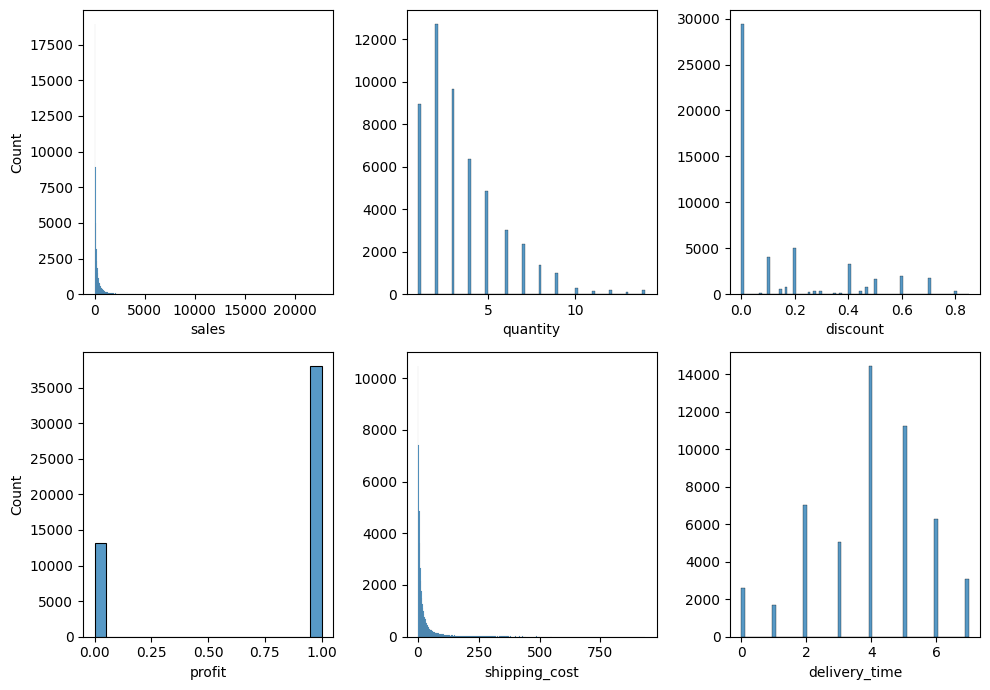

In [88]:
# Variables Numericas

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2,3,figsize = (10,7))

sns.histplot(ax = ax[0,0],data= df, x = 'sales')
sns.histplot(ax = ax[0,1],data= df, x = 'quantity').set(ylabel = None)
sns.histplot(ax = ax[0,2],data= df, x = 'discount').set(ylabel = None)
sns.histplot(ax = ax[1,0],data= df, x = 'profit')
sns.histplot(ax = ax[1,1],data= df, x = 'shipping_cost').set(ylabel = None)
sns.histplot(ax = ax[1,2],data= df, x = 'delivery_time').set(ylabel = None)

plt.tight_layout()
plt.show()

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ship_mode       51290 non-null  str    
 1   segment         51290 non-null  str    
 2   city            51290 non-null  str    
 3   state           51290 non-null  str    
 4   country         51290 non-null  str    
 5   market          51290 non-null  str    
 6   region          51290 non-null  str    
 7   category        51290 non-null  str    
 8   sub-category    51290 non-null  str    
 9   sales           51290 non-null  float64
 10  quantity        51290 non-null  int64  
 11  discount        51290 non-null  float64
 12  profit          51290 non-null  int64  
 13  shipping_cost   51290 non-null  float64
 14  order_priority  51290 non-null  str    
 15  delivery_time   51290 non-null  int64  
dtypes: float64(3), int64(3), str(10)
memory usage: 6.3 MB


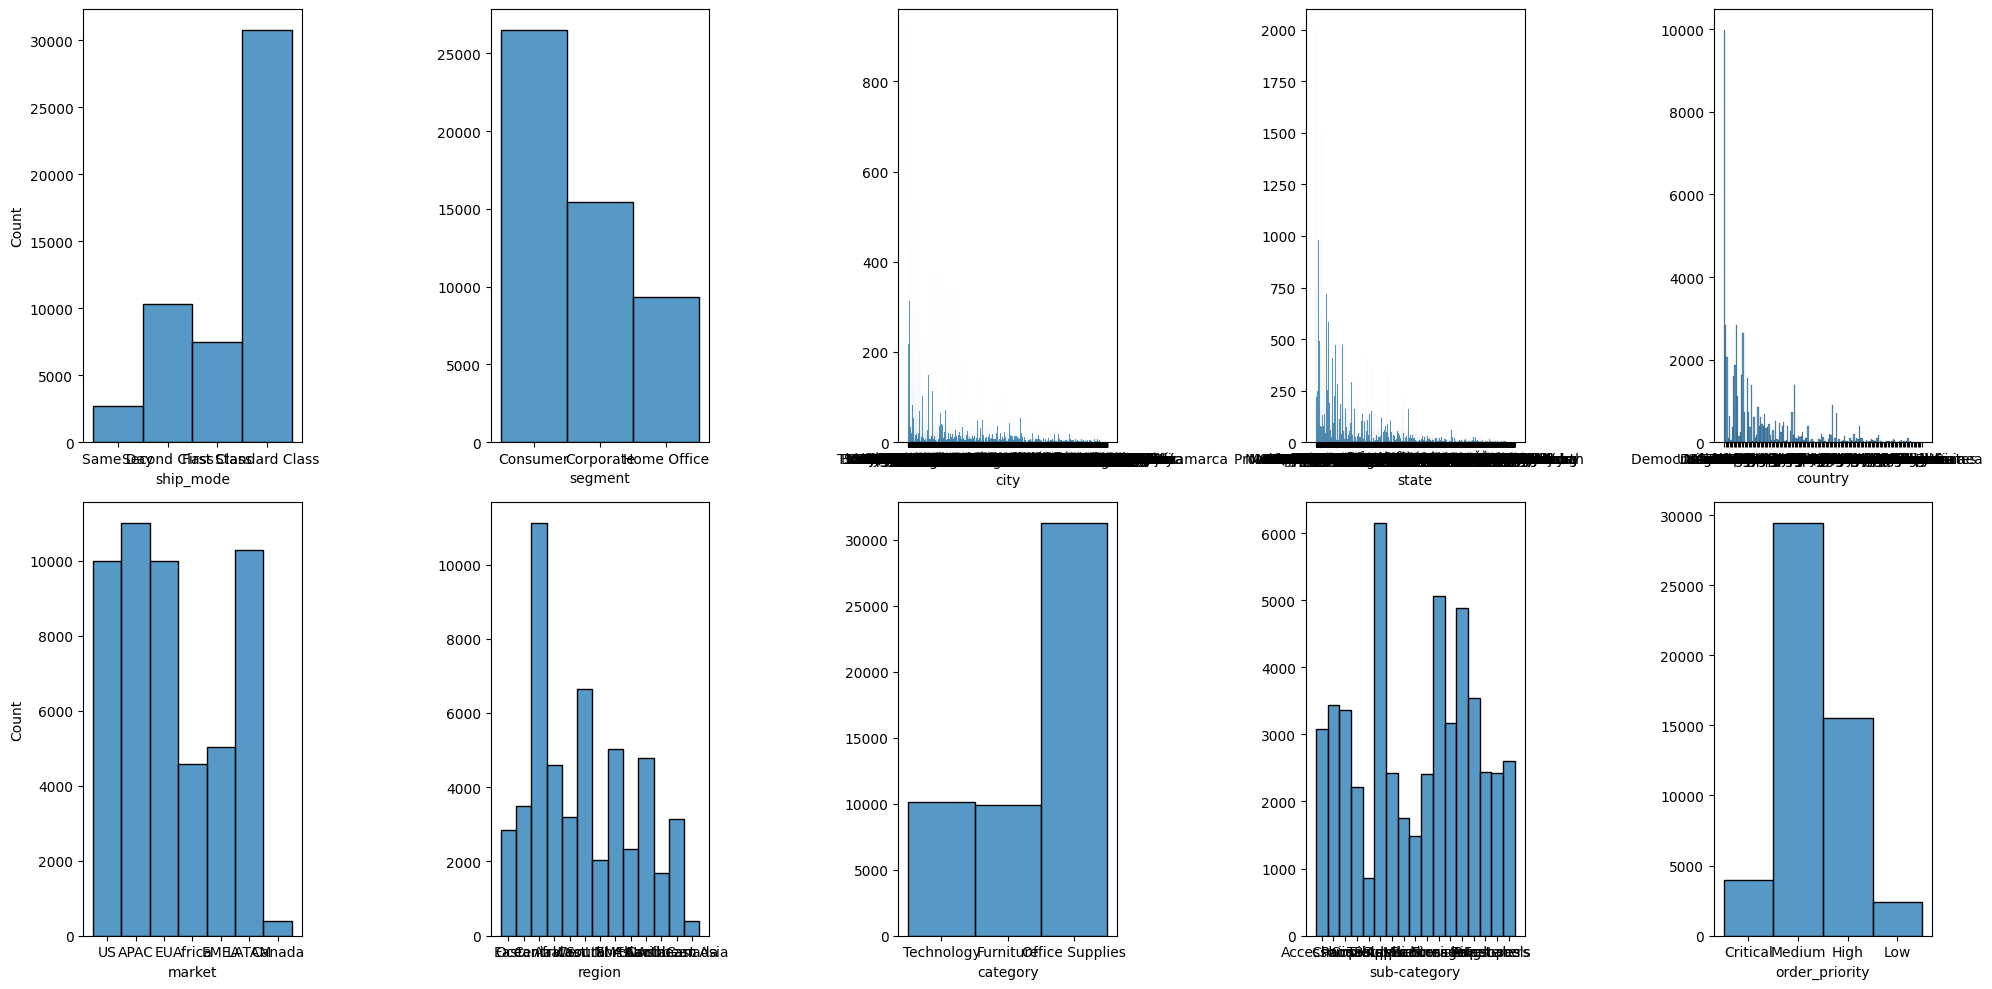

In [90]:
# Variables Categoricas
fig, ax = plt.subplots(2,5,figsize = (20,10))

sns.histplot(ax = ax[0,0],data= df, x = 'ship_mode')
sns.histplot(ax = ax[0,1],data= df, x = 'segment').set(ylabel = None)
sns.histplot(ax = ax[0,2],data= df, x = 'city').set(ylabel = None)
sns.histplot(ax = ax[0,3],data= df, x = 'state').set(ylabel = None)
sns.histplot(ax = ax[0,4],data= df, x = 'country').set(ylabel = None)
sns.histplot(ax = ax[1,0],data= df, x = 'market')
sns.histplot(ax = ax[1,1],data= df, x = 'region').set(ylabel = None)
sns.histplot(ax = ax[1,2],data= df, x = 'category').set(ylabel = None)
sns.histplot(ax = ax[1,3],data= df, x = 'sub-category').set(ylabel = None)
sns.histplot(ax = ax[1,4],data= df, x = 'order_priority').set(ylabel = None)

plt.tight_layout()
plt.show()

- City, State y Country se comportan de la misma forma, y dan la misma informacion. Nos quedaremos con uno solo

# Analisis Multivariante

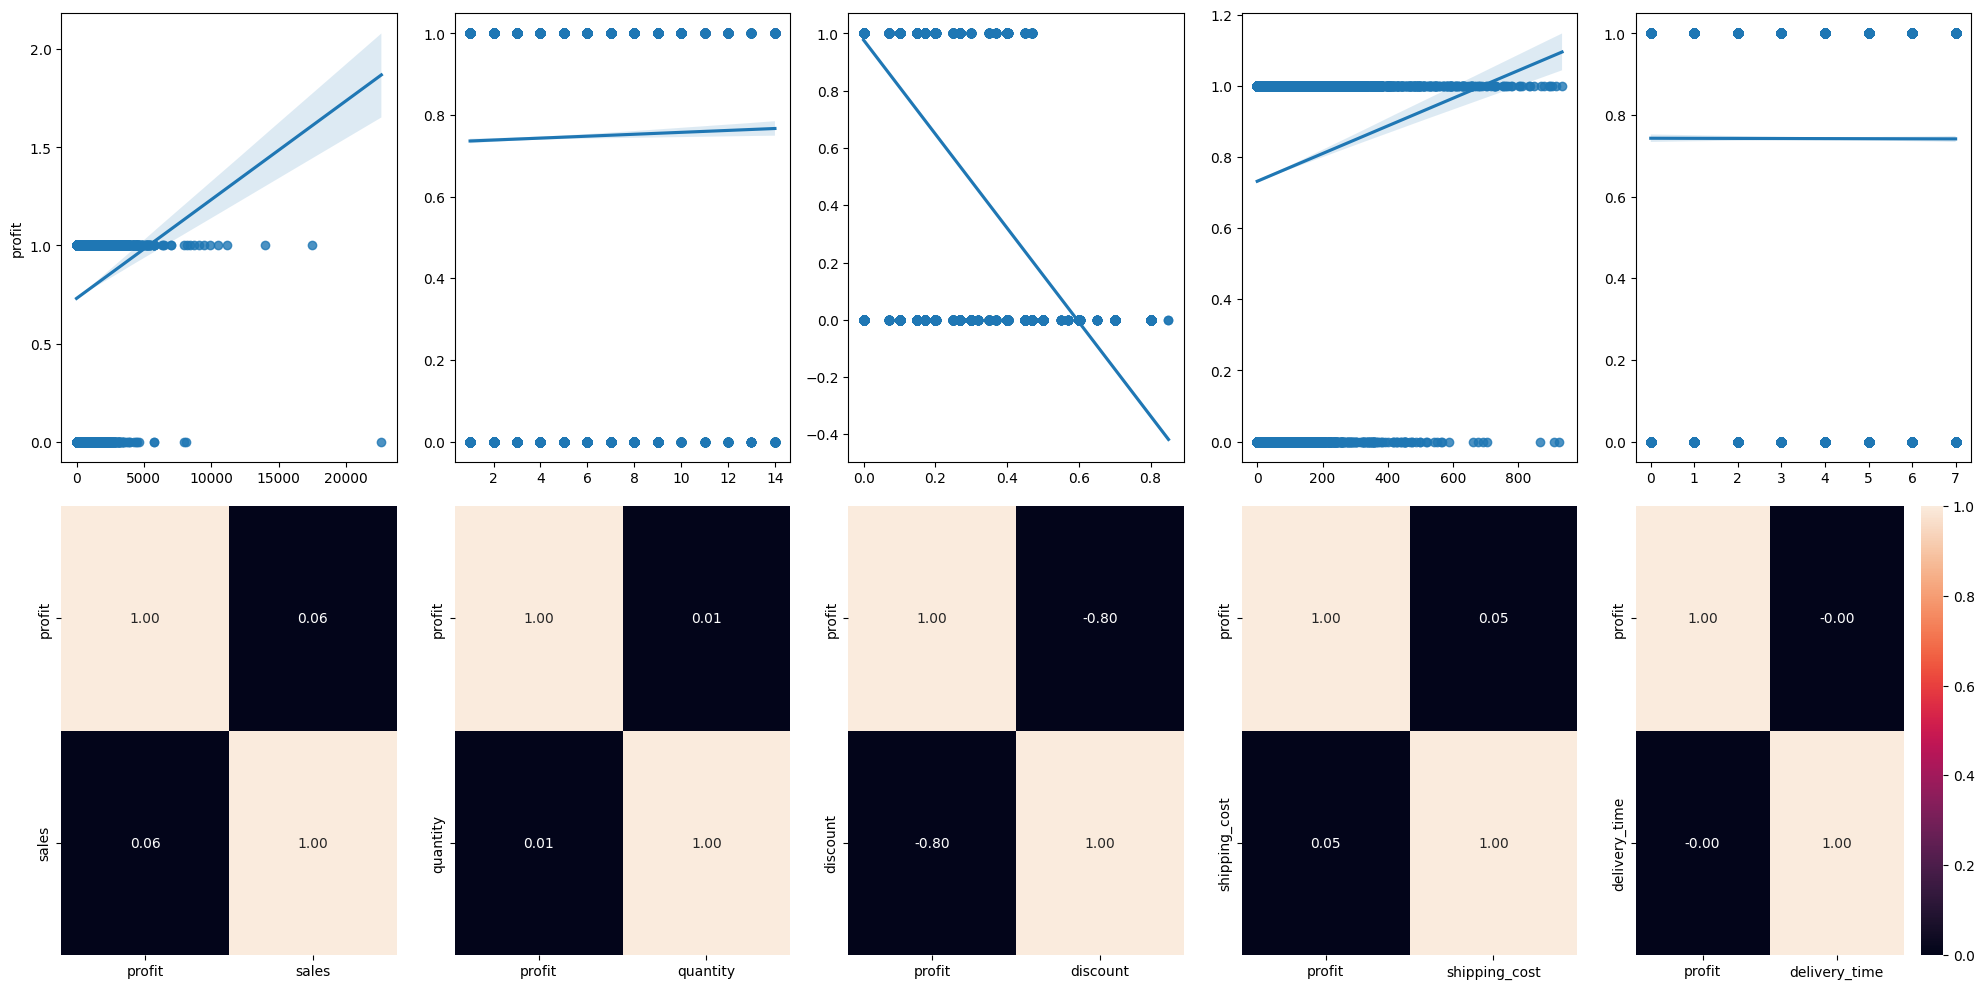

In [91]:
# Numerico - Numerico

fig, ax = plt.subplots(2,5,figsize = (20,10))

sns.regplot(ax = ax[0,0],data=df,x = 'sales', y = 'profit').set(xlabel = None)
sns.heatmap(df[['profit','sales']].corr(),annot= True,fmt='.2f',ax=ax[1,0], cbar=False)
sns.regplot(ax = ax[0,1],data=df,x = 'quantity', y = 'profit').set(xlabel = None, ylabel = None)
sns.heatmap(df[['profit','quantity']].corr(),annot= True,fmt='.2f',ax=ax[1,1], cbar=False)
sns.regplot(ax = ax[0,2],data=df,x = 'discount', y = 'profit').set(xlabel = None, ylabel = None)
sns.heatmap(df[['profit','discount']].corr(),annot= True,fmt='.2f',ax=ax[1,2], cbar=False)
sns.regplot(ax = ax[0,3],data=df,x = 'shipping_cost', y = 'profit').set(xlabel = None, ylabel = None)
sns.heatmap(df[['profit','shipping_cost']].corr(),annot= True,fmt='.2f',ax=ax[1,3], cbar=False)
sns.regplot(ax = ax[0,4],data=df,x = 'delivery_time', y = 'profit').set(xlabel = None, ylabel = None)
sns.heatmap(df[['profit','delivery_time']].corr(),annot= True,fmt='.2f',ax=ax[1,4])

plt.tight_layout()
plt.show()

In [92]:
# Vectorizado

df['ship_mode'] = pd.factorize(df['ship_mode'])[0]
df['segment'] = pd.factorize(df['segment'])[0]
df['city'] = pd.factorize(df['city'])[0]
df['state'] = pd.factorize(df['state'])[0]
df['country'] = pd.factorize(df['country'])[0]
df['market'] = pd.factorize(df['market'])[0]
df['region'] = pd.factorize(df['region'])[0]
df['category'] = pd.factorize(df['category'])[0]
df['sub-category'] = pd.factorize(df['sub-category'])[0]
df['order_priority'] = pd.factorize(df['order_priority'])[0]

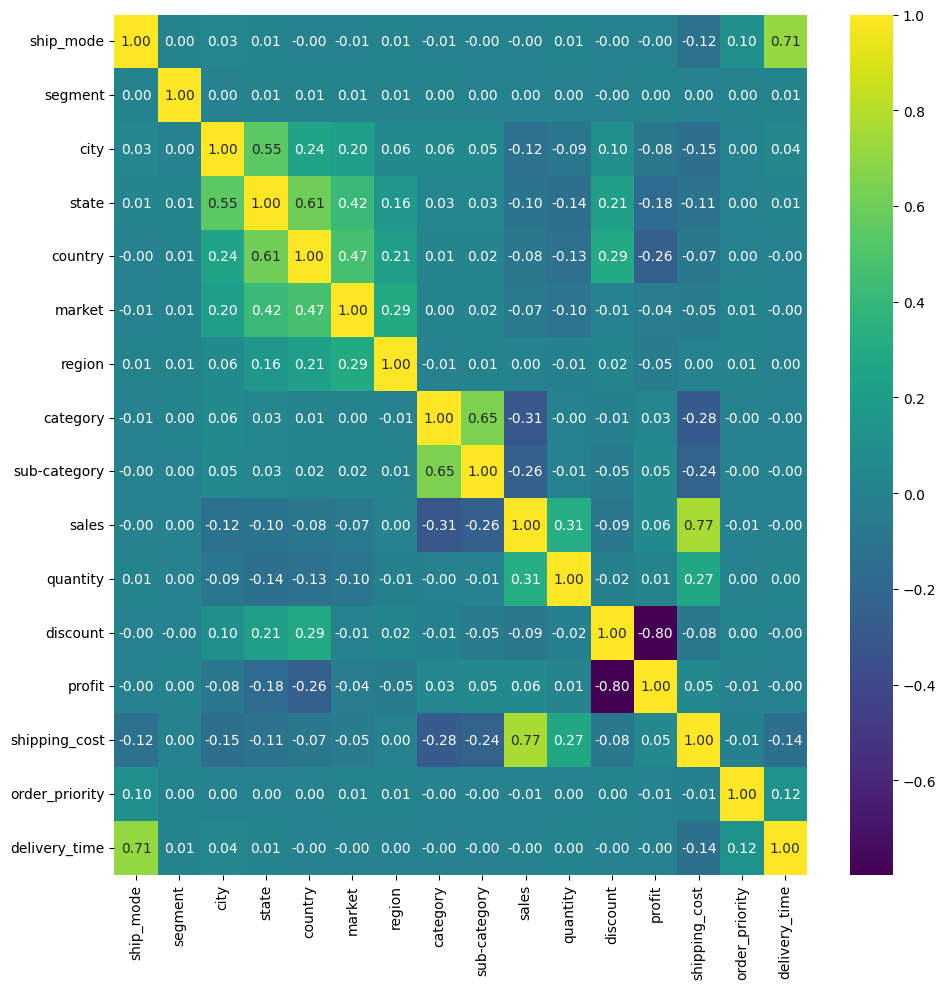

In [93]:
fig, ax = plt.subplots(figsize = (10,10))

sns.heatmap(df.corr(method='pearson'), annot=True,fmt='.2f',cmap='viridis',ax=ax)

plt.tight_layout()
plt.show()

In [94]:
df = df.drop(['country','city'], axis = 1)
df.head()

,ship_mode,segment,state,market,region,category,sub-category,sales,quantity,discount,profit,shipping_cost,order_priority,delivery_time
0,0,0,0,0,0,0,0,2309.650,7,0.0,1,933.57,0,0
1,1,1,1,1,1,1,1,3709.395,9,0.1,0,923.63,0,2
2,2,0,2,1,1,0,2,5175.171,9,0.1,1,915.49,1,1
3,2,2,3,2,2,0,2,2892.510,5,0.1,0,910.16,1,2
4,0,0,4,3,3,0,3,2832.960,8,0.0,1,903.04,0,1


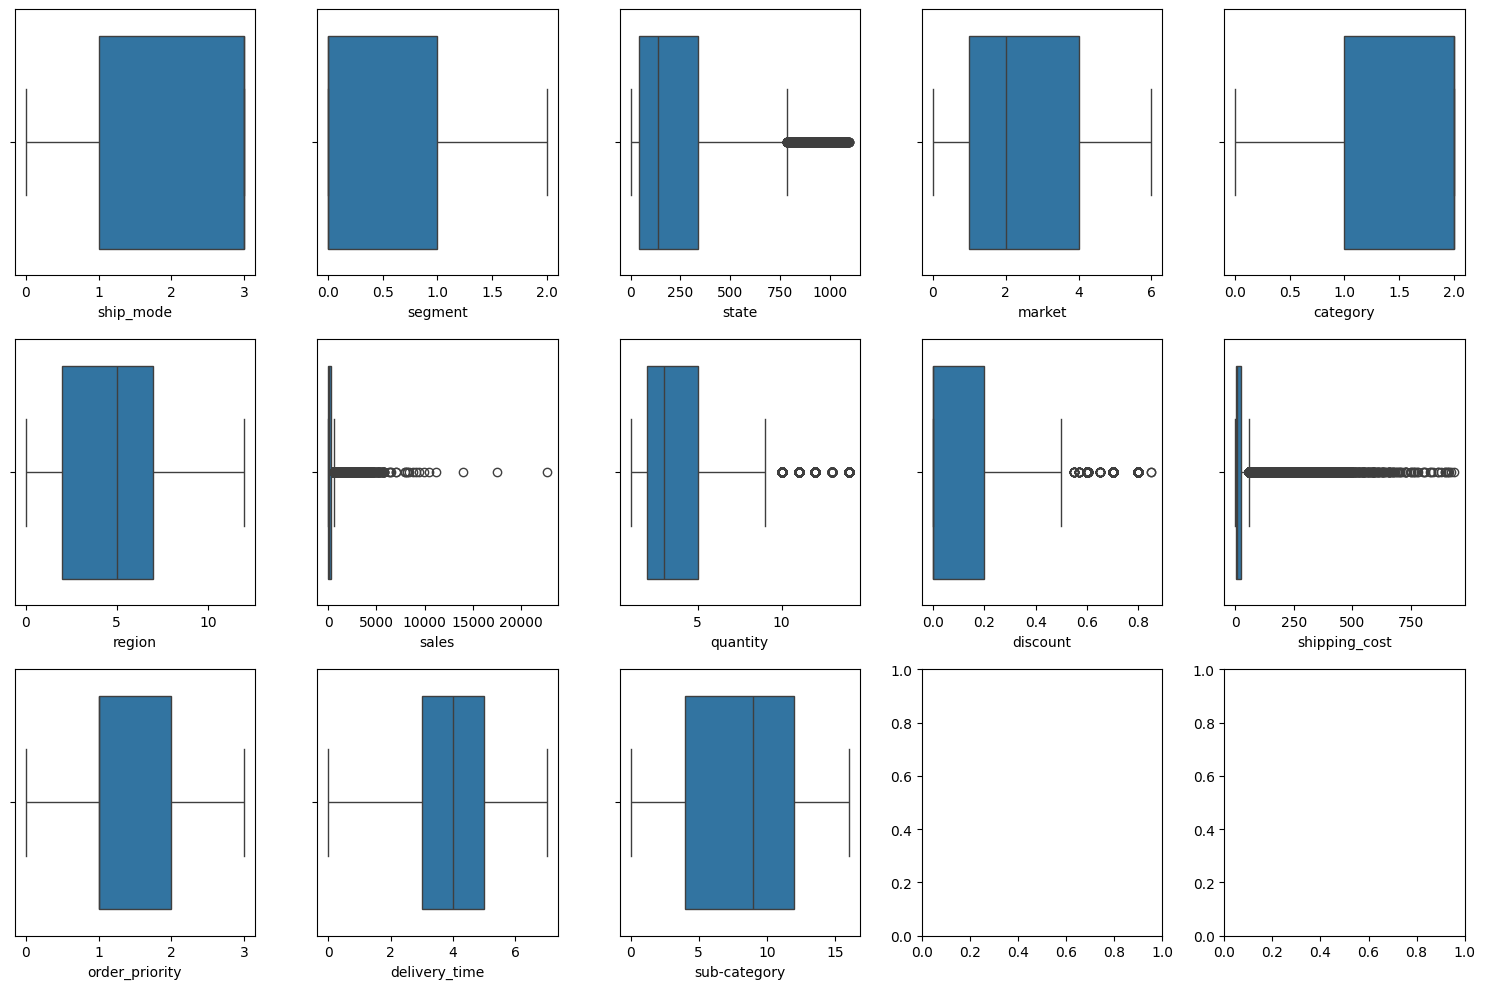

In [95]:
# Analisis de Outliers

fig , ax = plt.subplots(3,5,figsize=(15,10))

sns.boxplot(ax=ax[0,0], data= df, x = 'ship_mode')
sns.boxplot(ax=ax[0,1], data= df, x = 'segment')
sns.boxplot(ax=ax[0,2], data= df, x = 'state')
sns.boxplot(ax=ax[0,3], data= df, x = 'market')
sns.boxplot(ax=ax[0,4], data= df, x = 'category')
sns.boxplot(ax=ax[1,0], data= df, x = 'region')
sns.boxplot(ax=ax[1,1], data= df, x = 'sales')
sns.boxplot(ax=ax[1,2], data= df, x = 'quantity')
sns.boxplot(ax=ax[1,3], data= df, x = 'discount')
sns.boxplot(ax=ax[1,4], data= df, x = 'shipping_cost')
sns.boxplot(ax=ax[2,0], data= df, x = 'order_priority')
sns.boxplot(ax=ax[2,1], data= df, x = 'delivery_time')
sns.boxplot(ax=ax[2,2], data= df, x = 'sub-category')

plt.tight_layout()
plt.show()

- La mayoria de los outliers estan muy seguidos, por lo que no parecieran ser outliers. Y los descuentos mas altos son los que podrian generar mayores posibilidades de perdida. por lo que no se quitaran outliers

In [96]:
df = df.drop('sub-category', axis =1)

In [97]:
from sklearn.preprocessing import MinMaxScaler
x = df.drop('profit', axis =1)
scaler = MinMaxScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x), index=df.index, columns = x.columns)
x_scaled['profit'] = df['profit']
x_scaled.head()

,ship_mode,segment,state,market,region,category,sales,quantity,discount,shipping_cost,order_priority,delivery_time,profit
0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.102006,0.461538,0.000000,1.000000,0.000000,0.000000,1
1,0.333333,0.5,0.000915,0.166667,0.083333,0.5,0.163837,0.615385,0.117647,0.989353,0.000000,0.285714,0
2,0.666667,0.0,0.001830,0.166667,0.083333,0.0,0.228586,0.615385,0.117647,0.980633,0.333333,0.142857,1
3,0.666667,1.0,0.002745,0.333333,0.166667,0.0,0.127753,0.307692,0.117647,0.974924,0.333333,0.285714,0
4,0.000000,0.0,0.003660,0.500000,0.250000,0.0,0.125122,0.538462,0.000000,0.967298,0.000000,0.142857,1


In [98]:
from sklearn.model_selection import train_test_split

x = x_scaled.drop('profit', axis =1)
y = df['profit']

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# CORREMOS EL MODELO

In [99]:
# naive bayes BERNOULLINB porque nuestra variable objetivo es binaria

from sklearn.naive_bayes import BernoulliNB

model = BernoulliNB()
model.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [100]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)
accuracy_score(y_test,y_pred)

0.8211152271397933

# Hiperparametrizacion del modelo

In [101]:
# Busqueda Aleatoria

import numpy as np
from sklearn.model_selection import RandomizedSearchCV

hyper={
    'alpha': [0.5,0.7,1,2,3,4,5,6,7,8,9,10,11,12],
    'force_alpha': [False,True],
    'fit_prior':  [False,True],
}

random = RandomizedSearchCV(model,hyper, n_iter= 1000,scoring='accuracy', cv = 5, random_state=42)
random

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BernoulliNB()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': [0.5, 0.7, ...], 'fit_prior': [False, True], 'force_alpha': [False, True]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",1000
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None chang

In [102]:
random.fit(x_train,y_train)
print(f'Mejores parametros son:  {random.best_params_}')

/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 56 is smaller than n_iter=1000. Running 56 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Mejores parametros son:  {'force_alpha': False, 'fit_prior': True, 'alpha': 0.5}


In [103]:
model_2 = BernoulliNB(alpha=0,force_alpha=False,fit_prior=True)
model_2.fit(x_train,y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/naive_bayes.py:655: UserWarning: alpha too small will result in numeric errors, setting alpha = 1.0e-10. Use `force_alpha=True` to keep alpha unchanged.
  warnings.warn(


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",False
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [104]:
y_pred2 = model_2.predict(x_test)
accuracy_score(y_test,y_pred2)

0.8212127120296354